# A/B Testing Analysis: Marketing Campaign Effectiveness

## Business Problem

A company wants to determine whether displaying **advertisements (Ads)** leads to a higher **conversion rate** compared to showing **Public Service Announcements (PSA)**.

The goal of this analysis is to determine whether the **Ad strategy significantly increases user conversions**.

This will be evaluated using statistical hypothesis testing.

## Dataset Description

The dataset contains user-level experimental data from a marketing campaign.

Variables included:

| Column | Description |
|------|------|
| user id | Unique identifier for each user |
| test group | Experimental group (Ad or PSA) |
| converted | Whether the user converted |
| total ads | Number of ads shown to the user |
| most ads day | Day when the user saw the most ads |
| most ads hour | Hour when the user saw the most ads |

The main variables for the A/B test are:

- **test group**
- **converted**

## Importing Required Libraries

In [92]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep


## Loading the Dataset

In [94]:
df = pd.read_csv("marketing_ab.csv")

df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Dataset Overview

We first inspect the dataset structure to understand the variables, data types, and potential missing values.


In [95]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


In [96]:
df.shape


(588101, 7)

In [97]:
df.isnull().sum()


Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

## Data Preprocessing

The `converted` column is currently stored as a boolean variable.  
For statistical calculations, we convert it into a numerical format (1 = converted, 0 = not converted).


In [98]:
df["converted"] = df["converted"].astype(int)

df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,0,130,Monday,20
1,1,1119715,ad,0,93,Tuesday,22
2,2,1144181,ad,0,21,Tuesday,18
3,3,1435133,ad,0,355,Tuesday,10
4,4,1015700,ad,0,276,Friday,14


## Experimental Group Distribution

Before conducting the analysis, it is important to check whether the experiment groups are balanced.


In [99]:
df["test group"].value_counts()


test group
ad     564577
psa     23524
Name: count, dtype: int64

In [100]:
df["test group"].value_counts(normalize=True)


test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

## Conversion Rate by Experimental Group


In [101]:
conversion_rates = df.groupby("test group")["converted"].mean()

conversion_rates


test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

## Conversion Summary Table


In [102]:
summary = df.groupby("test group").agg(
    users=("converted","count"),
    conversions=("converted","sum"),
    conversion_rate=("converted","mean")
)

summary


,users,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


## Conversion Rate Visualization


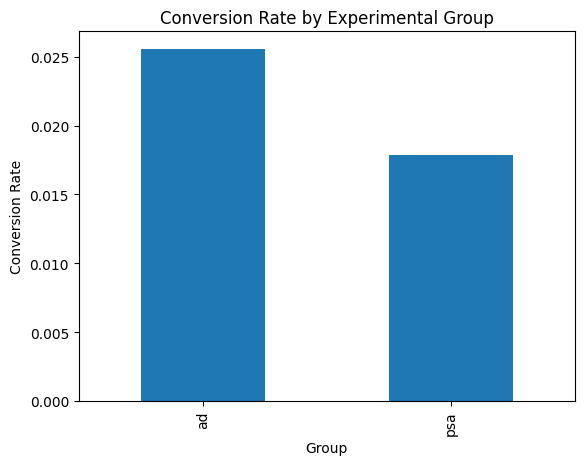

In [103]:
conversion_rates.plot(kind="bar")

plt.title("Conversion Rate by Experimental Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")

plt.show()


## Hypothesis Testing

We perform a **two-proportion Z-test** to determine whether the difference in conversion rates is statistically significant.

### Null Hypothesis



The advertisement strategy does **not** change the conversion rate.

### Alternative Hypothesis


The advertisement strategy **increases** the conversion rate.

### Significance Level
0.05

